In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/age_gender"

folders = [
    BASE_DIR,
    f"{BASE_DIR}/raw",
    f"{BASE_DIR}/preprocessed",
    f"{BASE_DIR}/labels",
    f"{BASE_DIR}/splits",
    f"{BASE_DIR}/models",
    f"{BASE_DIR}/logs"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

folders

['/content/drive/MyDrive/age_gender',
 '/content/drive/MyDrive/age_gender/raw',
 '/content/drive/MyDrive/age_gender/preprocessed',
 '/content/drive/MyDrive/age_gender/labels',
 '/content/drive/MyDrive/age_gender/splits',
 '/content/drive/MyDrive/age_gender/models',
 '/content/drive/MyDrive/age_gender/logs']

In [ ]:
!cp -r /content/part3/* /content/drive/MyDrive/age_gender/raw/

In [ ]:
!pip install lz4

In [ ]:
#!pip uninstall mtcnn
!pip install mtcnn

In [ ]:
import cv2
import numpy as np
from mtcnn import MTCNN
from tqdm import tqdm
import os
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

In [ ]:
RAW = "/content/drive/MyDrive/age_gender/raw"
PREP = "/content/drive/MyDrive/age_gender/preprocessed"

os.makedirs(PREP, exist_ok=True)

detector = MTCNN()

def preprocess_face(img, box, pad_ratio=0.25):
    x, y, w, h = box
    H, W = img.shape[:2]

    pad_w = int(w * pad_ratio)
    pad_h = int(h * pad_ratio)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(W, x + w + pad_w)
    y2 = min(H, y + h + pad_h)

    face = img[y1:y2, x1:x2]
    if face.size == 0:
        return None

    face = cv2.resize(face, (128, 128))
    return face

for age_group in os.listdir(RAW):
    src_folder = os.path.join(RAW, age_group)
    if not os.path.isdir(src_folder):
        continue

    dst_folder = os.path.join(PREP, age_group)
    os.makedirs(dst_folder, exist_ok=True)

    for fn in tqdm(os.listdir(src_folder), desc=f"Processing {age_group}"):
        img_path = os.path.join(src_folder, fn)
        img = cv2.imread(img_path)
        if img is None:
            continue

        det = detector.detect_faces(img)
        if not det:
            continue

        det = sorted(det, key=lambda d: d['box'][2] * d['box'][3], reverse=True)
        face = preprocess_face(img, det[0]['box'])
        if face is None:
            continue

        out_name = os.path.splitext(fn)[0] + ".jpg"
        cv2.imwrite(os.path.join(dst_folder, out_name), face)

print("✔ Preprocessing completed and ALL saved to Drive")

Processing 36+: 100%|██████████| 1660/1660 [13:04<00:00,  2.12it/s]

✔ Preprocessing completed and ALL saved to Drive


In [ ]:
import re
import pandas as pd

def extract_gender(fn):
    fn_l = fn.lower()

    m = re.search(r"_(0|1)_", fn_l)
    if m:
        return "male" if m.group(1) == "0" else "female"

    if fn_l.endswith("b.jpg") or "_b" in fn_l:
        return "male"
    if fn_l.endswith("g.jpg") or "_g" in fn_l:
        return "female"

    return None

rows = []

for age_group in os.listdir(PREP):
    folder = os.path.join(PREP, age_group)
    if not os.path.isdir(folder):
        continue

    for fn in os.listdir(folder):
        if not fn.endswith(".jpg"):
            continue

        gender = extract_gender(fn)
        if gender is None:
            continue

        rows.append([f"{age_group}/{fn}", age_group, gender])

df = pd.DataFrame(rows, columns=["filepath", "age_group", "gender"])
df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv", index=False)

df.head(), df["age_group"].value_counts()


(                                    filepath age_group  gender
 0  1-12/1_1_3_20161219230719040.jpg.chip.jpg      1-12  female
 1  1-12/9_0_0_20170110225318820.jpg.chip.jpg      1-12    male
 2  1-12/8_0_0_20170110220011635.jpg.chip.jpg      1-12    male
 3  1-12/5_1_2_20161219142021464.jpg.chip.jpg      1-12  female
 4  1-12/9_1_0_20170103212649164.jpg.chip.jpg      1-12  female,
 age_group
 1-12     2066
 36+      1480
 20-35    1478
 13-19     965
 Name: count, dtype: int64)

In [ ]:
PREP = "/content/drive/MyDrive/age_gender/preprocessed"
df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv")

df_clean = df[df["filepath"].apply(lambda x: os.path.exists(os.path.join(PREP, x)))]

df_clean.to_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv", index=False)

print("Before:", len(df))
print("After cleaning:", len(df_clean))

Before: 5989
After cleaning: 5989


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv")

target = df["age_group"].value_counts().max()

balanced = []
for ag, sub in df.groupby("age_group"):
    balanced.append(sub.sample(target, replace=True, random_state=42))

balanced_df = pd.concat(balanced).sample(frac=1).reset_index(drop=True)
balanced_df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_balanced.csv", index=False)

balanced_df["age_group"].value_counts()

,count
age_group,
13-19,2066
36+,2066
1-12,2066
20-35,2066


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    balanced_df, test_size=0.20, stratify=balanced_df["age_group"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["age_group"], random_state=42
)

train_df.to_csv("/content/drive/MyDrive/age_gender/splits/train.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/age_gender/splits/val.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/age_gender/splits/test.csv", index=False)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os

# **LOAD SPLITS**

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/age_gender/splits/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/age_gender/splits/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/age_gender/splits/test.csv")

## **Mappings**

In [ ]:
age_map = {"1-12":0, "13-19":1, "20-35":2, "36+":3}
gender_map = {"male":0, "female":1}

for df_ in [train_df, val_df, test_df]:
    df_["age_id"] = df_["age_group"].map(age_map)
    df_["gender_id"] = df_["gender"].map(gender_map)

# **IMAGE LOADER**

In [ ]:
def load_image(filepath, gender, age):
    full_path = "/content/drive/MyDrive/age_gender/preprocessed/" + filepath

    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (128, 128))
    img = img / 255.0

    return img, {
        "gender_output": gender,
        "age_output": age
    }

# **AUGMENTATIONS**

In [ ]:
base_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04)
])

In [ ]:
#def mixup(x, y, alpha=0.2):
#    lam = np.random.beta(alpha, alpha)
#    batch = tf.shape(x)[0]
#    idx = tf.random.shuffle(tf.range(batch))

 #   mixed_x = lam * x + (1 - lam) * tf.gather(x, idx)

 #   mixed_y = {
 #       "gender_output": lam * y["gender_output"] + (1 - lam) * tf.gather(y["gender_output"], idx),
 #       "age_output": y["age_output"]
  #  }
 #   return mixed_x, mixed_y

# **BUILD DATASET**

In [ ]:
def make_ds(df):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["filepath"], df["gender_id"], df["age_id"])
    )

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (base_aug(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_df)
val_ds   = make_ds(val_df)
test_ds  = make_ds(test_df)

In [ ]:
class DropBlock2D(layers.Layer):
    def __init__(self, drop_prob=0.1, block_size=5):
        super().__init__()
        self.drop_prob = drop_prob
        self.block_size = block_size

    def call(self, x, training=False):
        if not training:
            return x

        gamma = self.drop_prob / (self.block_size ** 2)
        mask = tf.cast(tf.random.uniform(tf.shape(x)[:3]) < gamma, x.dtype)
        mask = tf.expand_dims(mask, -1)
        mask = tf.nn.max_pool(mask, ksize=self.block_size, strides=1, padding="SAME")
        return x * (1 - mask)

In [ ]:
def res_block(x, filters):
    s = x

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, s])
    x = layers.ReLU()(x)
    x = DropBlock2D(0.1)(x)
    return x

In [ ]:
def build_model():
    inp = layers.Input((128,128,3))

    x = layers.Conv2D(32, 7, strides=2, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    x = res_block(x, 32)
    x = res_block(x, 32)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = res_block(x, 64)
    x = res_block(x, 64)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = res_block(x, 128)
    x = res_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)

    # Stronger dense head
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    gender_output = layers.Dense(2, activation="softmax", name="gender_output")(x)
    age_output = layers.Dense(4, activation="softmax", name="age_output")(x)

    return models.Model(inputs=inp, outputs=[gender_output, age_output])

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      4,736 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_block2d        │ (None, 32, 32,    │          0 │ re_lu_2[0][0]     │
│ (DropBlock2D)       │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      9,248 │ drop_block2d[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      9,248 │ re_lu_3[0][0]   

 Total params: 944,966 (3.60 MB)

 Trainable params: 943,110 (3.60 MB)

 Non-trainable params: 1,856 (7.25 KB)

# **OPTIMIZER + LOSSES**

In [ ]:
steps = len(train_df) // 32

lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=steps * 25
)

optimizer = tf.keras.optimizers.Adam(lr)

losses = {
    "gender_output": tf.keras.losses.SparseCategoricalCrossentropy(),
    "age_output": tf.keras.losses.SparseCategoricalCrossentropy()
}

loss_weights = {
    "gender_output": 1.0,
    "age_output": 3.0      # boosts underrepresented age groups
}

model.compile(
    optimizer=optimizer,
    loss=losses,
    loss_weights=loss_weights,
    metrics={
        "gender_output": "accuracy",
        "age_output": "accuracy"
    }
)

In [ ]:
'''def build_model():
    inp = layers.Input((128,128,3))

    x = layers.Conv2D(32, 7, strides=2, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    x = res_block(x, 32)
    x = res_block(x, 32)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = res_block(x, 64)
    x = res_block(x, 64)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = res_block(x, 128)
    x = res_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    gender_output = layers.Dense(2, activation="softmax", name="gender_output")(x)
    age_output = layers.Dense(4, activation="softmax", name="age_output")(x)

    return models.Model(inputs=inp, outputs=[gender_output, age_output])'''

'def build_model():\n    inp = layers.Input((128,128,3))\n\n    x = layers.Conv2D(32, 7, strides=2, padding="same")(inp)\n    x = layers.BatchNormalization()(x)\n    x = layers.ReLU()(x)\n    x = layers.MaxPool2D()(x)\n\n    x = res_block(x, 32)\n    x = res_block(x, 32)\n\n    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)\n    x = res_block(x, 64)\n    x = res_block(x, 64)\n\n    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)\n    x = res_block(x, 128)\n    x = res_block(x, 128)\n\n    x = layers.GlobalAveragePooling2D()(x)\n    x = layers.Dense(256, activation="relu")(x)\n    x = layers.Dropout(0.4)(x)\n\n    gender_output = layers.Dense(2, activation="softmax", name="gender_output")(x)\n    age_output = layers.Dense(4, activation="softmax", name="age_output")(x)\n\n    return models.Model(inputs=inp, outputs=[gender_output, age_output])'

# **CLASS WEIGHTS**

In [ ]:
'''steps = len(train_df) // 32

lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=steps * 35
)

optimizer = tf.keras.optimizers.Adam(lr)

losses = {
    "gender_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    "age_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
}'''

'steps = len(train_df) // 32\n\nlr = tf.keras.optimizers.schedules.CosineDecay(\n    initial_learning_rate=3e-4,\n    decay_steps=steps * 35\n)\n\noptimizer = tf.keras.optimizers.Adam(lr)\n\nlosses = {\n    "gender_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),\n    "age_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),\n}'

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/age_gender/models/model_v3.keras",
    monitor="val_age_output_accuracy",
    save_best_only=True,
    mode="max"
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[checkpoint_cb]
)

Epoch 1/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 512s 2s/step - age_output_accuracy: 0.4720 - age_output_loss: 1.1388 - gender_output_accuracy: 0.5987 - gender_output_loss: 0.6749 - loss: 4.0913 - val_age_output_accuracy: 0.2506 - val_age_output_loss: 7.3715 - val_gender_output_accuracy: 0.4758 - val_gender_output_loss: 0.8433 - val_loss: 22.9722
Epoch 2/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - age_output_accuracy: 0.6628 - age_output_loss: 0.7596 - gender_output_accuracy: 0.6671 - gender_output_loss: 0.6070 - loss: 2.8858 - val_age_output_accuracy: 0.5557 - val_age_output_loss: 1.2652 - val_gender_output_accuracy: 0.7119 - val_gender_output_loss: 0.5945 - val_loss: 4.3854
Epoch 3/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - age_output_accuracy: 0.6982 - age_output_loss: 0.6843 - gender_output_accuracy: 0.6996 - gender_output_loss: 0.5598 - loss: 2.6127 - val_age_output_accuracy: 0.7094 - val_age_output_loss: 0.6747 - val_gender_output_accuracy: 0.7264 - val_gender_output_loss: 0.5426 -

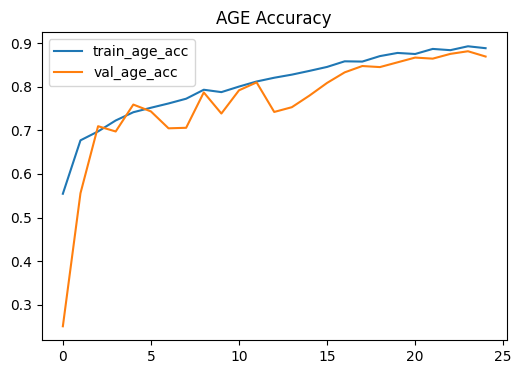

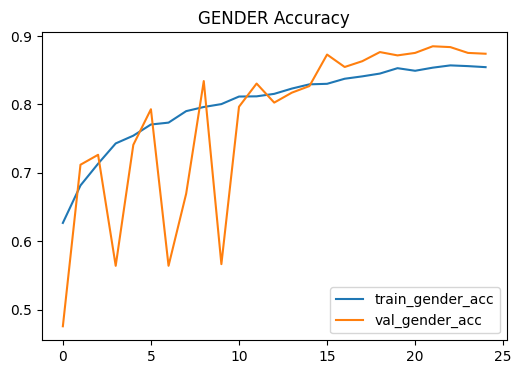

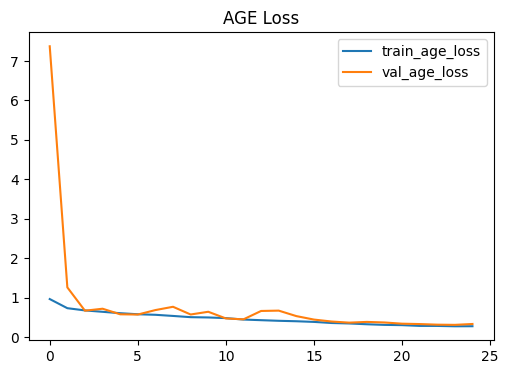

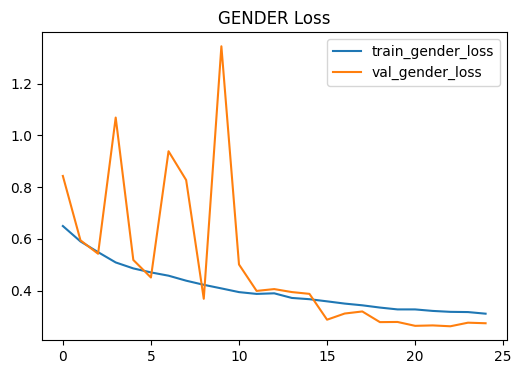

In [ ]:
import matplotlib.pyplot as plt

# --- AGE ACCURACY ---
plt.figure(figsize=(6,4))
plt.plot(history.history['age_output_accuracy'], label='train_age_acc')
plt.plot(history.history['val_age_output_accuracy'], label='val_age_acc')
plt.title("AGE Accuracy")
plt.legend()
plt.show()

# --- GENDER ACCURACY ---
plt.figure(figsize=(6,4))
plt.plot(history.history['gender_output_accuracy'], label='train_gender_acc')
plt.plot(history.history['val_gender_output_accuracy'], label='val_gender_acc')
plt.title("GENDER Accuracy")
plt.legend()
plt.show()

# --- AGE LOSS ---
plt.figure(figsize=(6,4))
plt.plot(history.history['age_output_loss'], label='train_age_loss')
plt.plot(history.history['val_age_output_loss'], label='val_age_loss')
plt.title("AGE Loss")
plt.legend()
plt.show()

# --- GENDER LOSS ---
plt.figure(figsize=(6,4))
plt.plot(history.history['gender_output_loss'], label='train_gender_loss')
plt.plot(history.history['val_gender_output_loss'], label='val_gender_loss')
plt.title("GENDER Loss")
plt.legend()
plt.show()


In [ ]:
train_age = history.history['age_output_accuracy'][-1]
val_age   = history.history['val_age_output_accuracy'][-1]

train_gender = history.history['gender_output_accuracy'][-1]
val_gender   = history.history['val_gender_output_accuracy'][-1]

print("Age train/val:", train_age, val_age)
print("Gender train/val:", train_gender, val_gender)

Age train/val: 0.8883678913116455 0.8692494034767151
Gender train/val: 0.8544849753379822 0.8740919828414917


In [ ]:
test_df = pd.read_csv("/content/drive/MyDrive/age_gender/splits/test.csv")

test_df["age_id"] = test_df["age_group"].map(age_map)
test_df["gender_id"] = test_df["gender"].map(gender_map)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"], test_df["gender_id"], test_df["age_id"])
).map(load_image).batch(32)

test_metrics = model.evaluate(test_ds)
test_metrics


26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 897ms/step - age_output_accuracy: 0.8871 - age_output_loss: 0.2998 - gender_output_accuracy: 0.8886 - gender_output_loss: 0.2670 - loss: 1.1663


[1.1303883790969849,
 0.2635551989078522,
 0.2886960208415985,
 0.8899637460708618,
 0.8839177489280701]

In [ ]:
model.save("/content/drive/MyDrive/age_gender/models/model_v3.keras", save_format="keras_v3")

In [ ]:
RAW_13 = "/content/drive/MyDrive/age_gender/raw/13-19"
PREP_13 = "/content/drive/MyDrive/age_gender/preprocessed/13-19"

In [ ]:
from mtcnn import MTCNN
import cv2, os
from tqdm import tqdm

detector = MTCNN()

def preprocess_face(img, box, pad_ratio=0.25):
    x, y, w, h = box
    H, W = img.shape[:2]

    pad_w = int(w * pad_ratio)
    pad_h = int(h * pad_ratio)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(W, x + w + pad_w)
    y2 = min(H, y + h + pad_h)

    face = img[y1:y2, x1:x2]
    if face.size == 0:
        return None

    face = cv2.resize(face, (128, 128))
    return face

for fn in tqdm(os.listdir(RAW_13)):
    src = os.path.join(RAW_13, fn)
    out_name = os.path.splitext(fn)[0] + ".jpg"
    dst = os.path.join(PREP_13, out_name)

    # Skip already processed images
    if os.path.exists(dst):
        continue

    img = cv2.imread(src)
    if img is None:
        continue

    det = detector.detect_faces(img)
    if not det:
        continue

    det = sorted(det, key=lambda d: d['box'][2] * d['box'][3], reverse=True)
    face = preprocess_face(img, det[0]['box'])
    if face is not None:
        cv2.imwrite(dst, face)


100%|██████████| 1014/1014 [01:06<00:00, 15.28it/s]


In [ ]:
import os, re, pandas as pd

PREP = "/content/drive/MyDrive/age_gender/preprocessed"
rows = []

def extract_gender(fn):
    fn_low = fn.lower()

    m = re.search(r"_(0|1)_", fn_low)
    if m:
        return "male" if m.group(1) == "0" else "female"

    if "_b" in fn_low:
        return "male"
    if "_g" in fn_low:
        return "female"

    return None

for age_group in os.listdir(PREP):
    folder = os.path.join(PREP, age_group)
    if not os.path.isdir(folder):
        continue

    for fn in os.listdir(folder):
        if fn.endswith(".jpg"):
            gender = extract_gender(fn)
            if gender:
                rows.append([f"{age_group}/{fn}", age_group, gender])

df = pd.DataFrame(rows, columns=["filepath", "age_group", "gender"])
df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv", index=False)

In [ ]:
PREP = "/content/drive/MyDrive/age_gender/preprocessed"

df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv")
df_clean = df[df["filepath"].apply(lambda x: os.path.exists(os.path.join(PREP, x)))]

df_clean.to_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv", index=False)

print("Before:", len(df))
print("After:", len(df_clean))

Before: 5932
After: 5932


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv")

max_count = df["age_group"].value_counts().max()

balanced = []
for ag, sub in df.groupby("age_group"):
    balanced.append(sub.sample(max_count, replace=True, random_state=42))

balanced_df = pd.concat(balanced).sample(frac=1).reset_index(drop=True)
balanced_df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_balanced.csv", index=False)

balanced_df["age_group"].value_counts()

NameError: name 'pd' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_balanced.csv")

train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["age_group"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["age_group"], random_state=42
)

train_df.to_csv("/content/drive/MyDrive/age_gender/splits/train.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/age_gender/splits/val.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/age_gender/splits/test.csv", index=False)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

class DropBlock2D(layers.Layer):
    def __init__(self, drop_prob=0.1, block_size=5, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob
        self.block_size = block_size

    def call(self, x, training=False):
        if not training:
            return x
        gamma = self.drop_prob / (self.block_size ** 2)
        mask = tf.cast(tf.random.uniform(tf.shape(x)[:3]) < gamma, x.dtype)
        mask = tf.expand_dims(mask, -1)
        mask = tf.nn.max_pool(mask, ksize=self.block_size, strides=1, padding="SAME")
        return x * (1 - mask)

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/best_model.h5",
    custom_objects={'DropBlock2D': DropBlock2D},
    compile=False
)

In [ ]:
model.save("/content/drive/MyDrive/age_gender/models/model_v1.keras", save_format="keras_v3")

# **FEW SHOT LEARNING ON OCCLUSION**

In [ ]:
import os
import cv2
from mtcnn import MTCNN
from tqdm import tqdm

RAW = "/content/drive/MyDrive/age_gender/occlusion_finetune"
PREP = "/content/drive/MyDrive/age_gender/occlusion_finetune_preprocessed"

os.makedirs(PREP, exist_ok=True)
detector = MTCNN()

IMG_SIZE = 128

def preprocess_face(img, box, pad_ratio=0.25):
    x, y, w, h = box
    H, W = img.shape[:2]

    pad_w = int(w * pad_ratio)
    pad_h = int(h * pad_ratio)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(W, x + w + pad_w)
    y2 = min(H, y + h + pad_h)

    face = img[y1:y2, x1:x2]
    if face.size == 0:
        return None

    return cv2.resize(face, (IMG_SIZE, IMG_SIZE))

for age_group in os.listdir(RAW):
    src_dir = os.path.join(RAW, age_group)
    if not os.path.isdir(src_dir):
        continue

    dst_dir = os.path.join(PREP, age_group)
    os.makedirs(dst_dir, exist_ok=True)

    for fn in tqdm(os.listdir(src_dir), desc=f"Processing {age_group}"):
        img_path = os.path.join(src_dir, fn)
        img = cv2.imread(img_path)
        if img is None:
            continue

        dets = detector.detect_faces(img)
        if not dets:
            continue

        # Largest face only
        dets = sorted(dets, key=lambda d: d["box"][2] * d["box"][3], reverse=True)
        face = preprocess_face(img, dets[0]["box"])
        if face is None:
            continue

        out = os.path.splitext(fn)[0] + ".jpg"
        cv2.imwrite(os.path.join(dst_dir, out), face)

print("✔ Few-shot preprocessing complete!")

Processing 36+: 100%|██████████| 18/18 [00:14<00:00,  1.26it/s]

✔ Few-shot preprocessing complete!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Load base model
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/model_v3.keras",
    custom_objects={"DropBlock2D": DropBlock2D},
    compile=False
)

print("Loaded model_v3.keras")

Loaded model_v3.keras


In [ ]:
# Freeze ALL layers first
for layer in model.layers:
    layer.trainable = False

# Selectively unfreeze last layers (no batchnorm)
trainable_count = 0
for layer in model.layers[-15:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
        trainable_count += 1

print("Trainable layers:", trainable_count)

Trainable layers: 13


In [ ]:
'''import os
import tensorflow as tf

IMG_SIZE = 128
BATCH = 8

# ---------------------------------------------------------
# 1. Build file list
# ---------------------------------------------------------
base = "/content/drive/MyDrive/age_gender/occlusion_finetune_preprocessed"

fewshot_paths = []

for grp in ["1-12", "13-19", "20-35", "36+"]:
    folder = f"{base}/{grp}"
    if not os.path.exists(folder):
        print("❌ Missing folder:", folder)
        continue

    for f in os.listdir(folder):
        if f.lower().endswith(".jpg"):
            fewshot_paths.append(os.path.join(folder, f))

print("Few-shot samples:", len(fewshot_paths))


# ---------------------------------------------------------
# 2. Label extraction function (Python side)
# ---------------------------------------------------------
def load_and_label(path):
    path = path.numpy().decode()

    # --- Load & preprocess image ---
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    # --- Extract age group from folder ---
    age_group = path.split("/")[-2]
    age_map = {"1-12": 0, "13-19": 1, "20-35": 2, "36+": 3}
    age_label = age_map[age_group]

    # --- Extract gender from filename ---
    fname = path.split("/")[-1].lower()

    fname = path.split("/")[-1].lower()

    # Allow _b, _b_, b_, _g, g_, etc.
    if "_b" in fname or "b_" in fname:
        gender_label = 0    # male
    elif "_g" in fname or "g_" in fname:
        gender_label = 1    # female
    else:
        raise ValueError(f"❌ Could not detect gender from filename: {fname}")

    return img, gender_label, age_label


# ---------------------------------------------------------
# 3. Parse record (TensorFlow side)
# ---------------------------------------------------------
def parse_record(path):
    img, gender, age = tf.py_function(
        load_and_label,
        [path],
        [tf.float32, tf.int32, tf.int32]
    )

    # 🔥 VERY IMPORTANT: set shapes manually
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    gender.set_shape([])
    age.set_shape([])

    return img, gender, age


# ---------------------------------------------------------
# 4. Build raw dataset
# ---------------------------------------------------------
fewshot_ds = tf.data.Dataset.from_tensor_slices(fewshot_paths)
fewshot_ds = fewshot_ds.shuffle(len(fewshot_paths))
fewshot_ds = fewshot_ds.map(parse_record, num_parallel_calls=tf.data.AUTOTUNE)


# ---------------------------------------------------------
# 5. Convert to model format (dual output)
# ---------------------------------------------------------
def format_labels(img, gender, age):
    return img, {
        "gender_output": gender,
        "age_output": age
    }

fewshot_ds = fewshot_ds.map(format_labels)
fewshot_ds = fewshot_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("✔ Few-shot dataset ready!")'''

Few-shot samples: 110
✔ Few-shot dataset ready!


In [ ]:
import os
import tensorflow as tf

IMG_SIZE = 128
BATCH  = 8

# -------------------------
# Folder Structure
# -------------------------
base = "/content/drive/MyDrive/age_gender/occlusion_finetune_preprocessed"

fewshot_paths = []
for grp in ["1-12", "13-19", "20-35", "36+"]:
    folder = f"{base}/{grp}"
    if not os.path.exists(folder):
        print("❌ Missing:", folder)
        continue

    for f in os.listdir(folder):
        if f.lower().endswith(".jpg"):
            fewshot_paths.append(os.path.join(folder, f))

print("Few-shot samples:", len(fewshot_paths))


# -------------------------
# Python label function
# -------------------------
def load_and_label(path):
    path = path.numpy().decode()

    # Load image
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    # Age group from directory name
    age_group = path.split("/")[-2]
    age_map = {"1-12":0, "13-19":1, "20-35":2, "36+":3}
    age_label = age_map[age_group]

    # Gender from filename
    fname = path.split("/")[-1].lower()
    if "_b" in fname:
        gender = 0
    elif "_g" in fname:
        gender = 1
    else:
        raise ValueError("❌ Filename must contain _b or _g : " + fname)

    return img, gender, age_label


# -------------------------
# TensorFlow parsing wrapper
# -------------------------
def parse_record(path):
    img, g, a = tf.py_function(
        load_and_label, [path], [tf.float32, tf.int32, tf.int32]
    )

    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    g.set_shape([])
    a.set_shape([])

    return img, {"gender_output": g, "age_output": a}


# -------------------------
# Build TF dataset
# -------------------------
fewshot_ds = tf.data.Dataset.from_tensor_slices(fewshot_paths)
fewshot_ds = fewshot_ds.shuffle(len(fewshot_paths))
fewshot_ds = fewshot_ds.map(parse_record, num_parallel_calls=tf.data.AUTOTUNE)
fewshot_ds = fewshot_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("✔ Few-shot dataset ready!")

Few-shot samples: 110
✔ Few-shot dataset ready!


In [ ]:
'''for batch in fewshot_ds.take(1):
    print("image batch:", batch[0].shape)
    print("gender batch:", batch[1]["gender_output"].shape)
    print("age batch:", batch[1]["age_output"].shape)'''

image batch: (8, 128, 128, 3)
gender batch: (8,)
age batch: (8,)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        "gender_output": tf.keras.losses.SparseCategoricalCrossentropy(),
        "age_output": tf.keras.losses.SparseCategoricalCrossentropy()
    },
    metrics={
        "gender_output": "accuracy",
        "age_output": "accuracy"
    }
)

In [ ]:
history = model.fit(
    fewshot_ds,
    epochs=10
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 396ms/step - age_output_accuracy: 0.6070 - age_output_loss: 1.0136 - gender_output_accuracy: 0.8119 - gender_output_loss: 0.4006 - loss: 1.4145
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - age_output_accuracy: 0.7101 - age_output_loss: 0.8324 - gender_output_accuracy: 0.8333 - gender_output_loss: 0.3621 - loss: 1.1954
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - age_output_accuracy: 0.6590 - age_output_loss: 1.0414 - gender_output_accuracy: 0.8991 - gender_output_loss: 0.3113 - loss: 1.3511
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - age_output_accuracy: 0.6515 - age_output_loss: 0.9546 - gender_output_accuracy: 0.8271 - gender_output_loss: 0.3778 - loss: 1.3328
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - age_output_accuracy: 0.6504 - age_output_loss: 0.9151 - gender_output_accuracy: 0.8492 - gender_output_loss: 0.3563 - loss: 1.2701
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - age_output_accuracy: 

In [ ]:
model.save("/content/drive/MyDrive/age_gender/models/model_v3_fewshot.keras")

print("Few-shot finetuned model saved!")

Few-shot finetuned model saved!


# **EVALUATION BEFORE VS AFTER FINE TUNING**

In [ ]:
PREP_PATH = "/content/drive/MyDrive/age_gender/preprocessed"

In [ ]:
import os
import tensorflow as tf
import pandas as pd
import numpy as np

# Load val csv
val_df = pd.read_csv("/content/drive/MyDrive/age_gender/splits/val.csv")

# Build correct full paths
val_df["full_path"] = val_df["filepath"].apply(
    lambda x: os.path.join(PREP_PATH, x)
)

print(val_df["full_path"].head())


0    /content/drive/MyDrive/age_gender/preprocessed...
1    /content/drive/MyDrive/age_gender/preprocessed...
2    /content/drive/MyDrive/age_gender/preprocessed...
3    /content/drive/MyDrive/age_gender/preprocessed...
4    /content/drive/MyDrive/age_gender/preprocessed...
Name: full_path, dtype: object


In [ ]:
age_map = {"1-12":0, "13-19":1, "20-35":2, "36+":3}
gender_map = {"male":0, "female":1}

val_df["age_label"] = val_df["age_group"].map(age_map)
val_df["gender_label"] = val_df["gender"].map(gender_map)

In [ ]:
IMG_SIZE = 128

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0


In [ ]:
val_imgs = tf.data.Dataset.from_tensor_slices(val_df["full_path"])
val_imgs = val_imgs.map(load_image).batch(32)

y_true_age = val_df["age_label"].values
y_true_gender = val_df["gender_label"].values

In [ ]:
base_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/model_v3.keras",
    custom_objects={"DropBlock2D": DropBlock2D}
)

ft_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/model_v3_fewshot.keras",
    custom_objects={"DropBlock2D": DropBlock2D}
)

print("Loaded both models successfully!")

Loaded both models successfully!


In [ ]:
pred_v1 = base_model.predict(val_imgs)
pred_v2 = ft_model.predict(val_imgs)

gender_pred_v1 = np.argmax(pred_v1[0], axis=1)
gender_pred_v2 = np.argmax(pred_v2[0], axis=1)

age_pred_v1 = np.argmax(pred_v1[1], axis=1)
age_pred_v2 = np.argmax(pred_v2[1], axis=1)

# Accuracy
acc_v1_gender = np.mean(gender_pred_v1 == y_true_gender)
acc_v1_age    = np.mean(age_pred_v1 == y_true_age)

acc_v2_gender = np.mean(gender_pred_v2 == y_true_gender)
acc_v2_age    = np.mean(age_pred_v2 == y_true_age)

print("V1 Gender Accuracy:", acc_v1_gender)
print("V1 Age Accuracy:", acc_v1_age)

print("V2 Gender Accuracy:", acc_v2_gender)
print("V2 Age Accuracy:", acc_v2_age)

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step
V1 Gender Accuracy: 0.8789346246973365
V1 Age Accuracy: 0.8813559322033898
V2 Gender Accuracy: 0.8777239709443099
V2 Age Accuracy: 0.864406779661017
